# Wine Quality Classification
Petunjuk:
1. Dalam ujian ini, Anda diminta untuk membuat model klasifikasi untuk memprediksi kualitas anggur. Dataset yang digunakan adalah dataset Wine Quality yang berisi fitur-fitur kimiawi dari anggur merah dan putih serta nilai kualitasnya.
2. Dataset ini berisi data tentang kualitas anggur merah dan putih, dengan variabel-variabel kimiawi yang diukur dari setiap sampel anggur. Variabel target yang akan diprediksi adalah quality, yang menunjukkan kualitas anggur dari skala 0 hingga 10.
3. Anda akan diberikan 2 data_testing.csv yang berisi fitur kimiawi anggur, namun tanpa label kualitas. Tugas Anda adalah memprediksi nilai kualitas untuk data testing tersebut.
4. Setiap proses yang anda lakukan didokumentasikan di notebook dengan penjelasan dan interpretasi, yang harus diupload di akun github masing-masing.
5. Hasil prediksi anda disimpan dalam format csv yang HANYA MEMUAT 2 variabel yaitu id dan quality (hasil prediksi).
6. Kumpulkan link github dan csv hasil prediksi pada form yang telah diberikan.

## 1. Persiapan Data
Anda diberikan 2 dataset yaitu dataset training dan dataset testing. Anda harus membuat model klasifikasi dengan dataset training. Simpanlah model yang anda buat dan lakukan deployment model tersebut pada dataset testing yang sudah disediakan. Dataset dapat diunduh pada tautan berikut: https://bit.ly/datasetwine

In [16]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)

warnings.filterwarnings('ignore')
print("Semua library berhasil diimport")

Semua library berhasil diimport


In [9]:
# Load data
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f"Training shape : {train.shape}")
print(f"Testing  shape : {test.shape}")
train.head()

Training shape : (857, 13)
Testing  shape : (286, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


## 2. Pembersihan Data
Pastikan tidak ada nilai yang hilang (missing values) pada dataset. Jika ada, lakukan penanganan yang sesuai (misalnya, imputasi atau penghapusan data yang hilang). Periksa apakah ada fitur yang memerlukan normalisasi atau skala ulang (feature scaling), terutama jika nilai-nilai fitur sangat bervariasi.

In [10]:
# Cek missing values
print("=== Missing Values — Training ===")
print(train.isnull().sum())
print("=== Missing Values — Testing ===")
print(test.isnull().sum())
print("Tidak ada missing values pada kedua dataset. Tidak diperlukan imputasi.")

=== Missing Values — Training ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
=== Missing Values — Testing ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64
Tidak ada missing values pada kedua dataset. Tidak diperlukan imputasi.


In [11]:
# Statistik Desekriptif
"""
Untuk membantu memahami distribusi setiap fitur termasuk
nilai minimum, maksimum, rata-rata, dan standar deviasi
"""
train.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.000000,8.261960,1.701992,4.600000,7.100000,7.900000,9.100000,15.600000
volatile acidity,857.000000,0.529393,0.179162,0.120000,0.395000,0.520000,0.640000,1.580000
citric acid,857.000000,0.267351,0.195144,0.000000,0.090000,0.250000,0.420000,1.000000
residual sugar,857.000000,2.506184,1.293512,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,857.000000,0.086830,0.048721,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,857.000000,15.782964,10.300402,1.000000,7.000000,14.000000,21.000000,68.000000
total sulfur dioxide,857.000000,45.978413,31.692113,6.000000,21.000000,38.000000,63.000000,278.000000
density,857.000000,0.996692,0.001901,0.990070,0.995520,0.996680,0.997800,1.003200
pH,857.000000,3.313092,0.152079,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,857.000000,0.656709,0.167364,0.390000,0.550000,0.620000,0.730000,2.000000


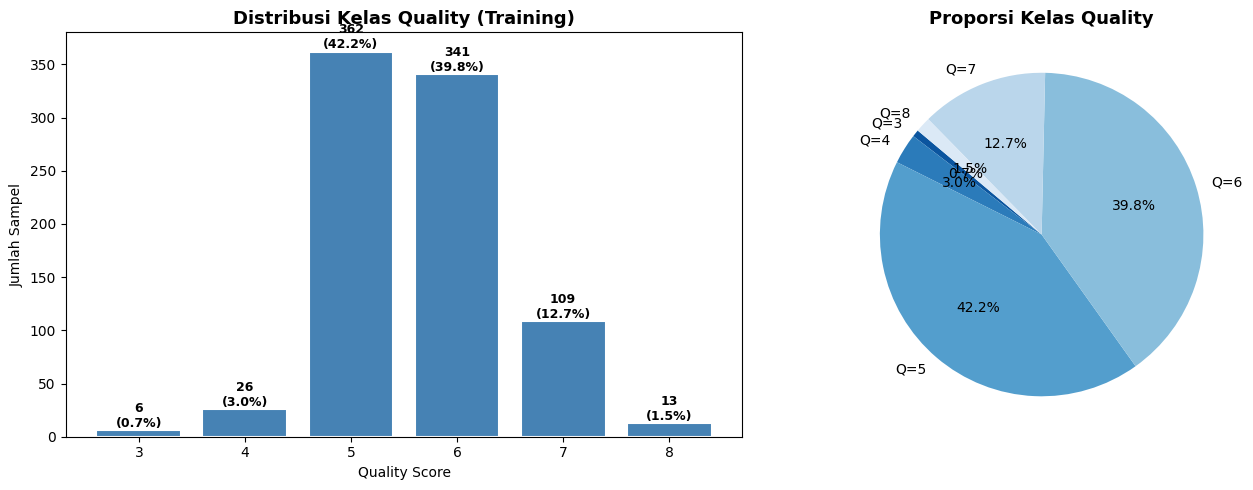


Keterangan: Kelas 5 dan 6 mendominasi (~82%). Ini adalah class imbalance.


In [12]:
# Distribusi Variabel Target (quality)
" Untuk memahami distribusi kelas 'quality' untuk mendeteksi ketidakseimbangan kelas"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = train['quality'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white', linewidth=1.5)
for i, v in zip(vc.index, vc.values):
    axes[0].text(i, v + 3, f'{v}\n({v/len(train)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribusi Kelas Quality (Training)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Quality Score'); axes[0].set_ylabel('Jumlah Sampel')

axes[1].pie(vc.values, labels=[f'Q={i}' for i in vc.index],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_r', len(vc)))
axes[1].set_title('Proporsi Kelas Quality', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("\nKeterangan: Kelas 5 dan 6 mendominasi (~82%). Ini adalah class imbalance.")

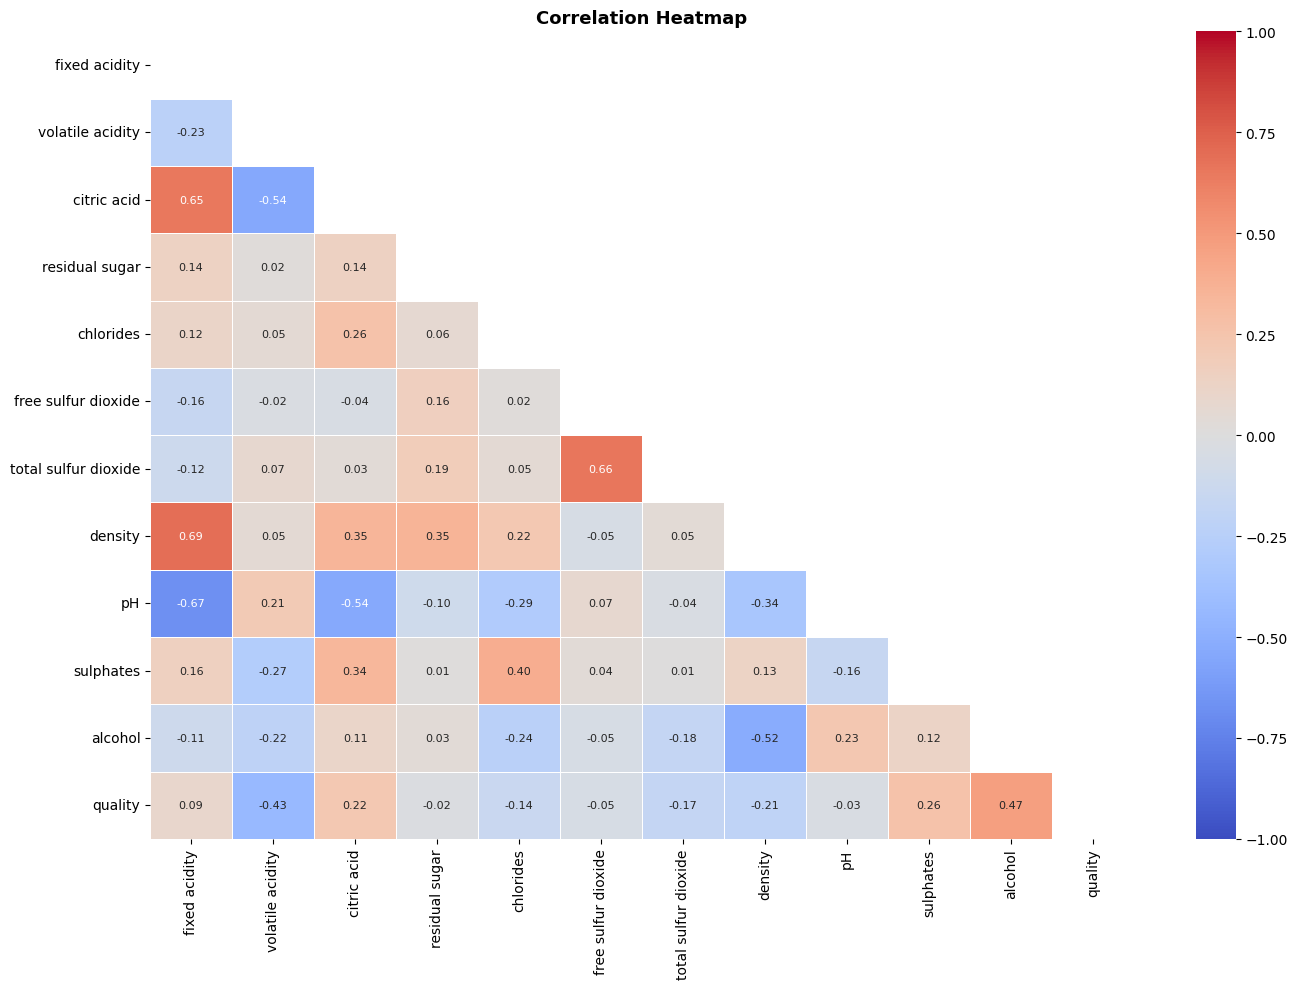

Korelasi dengan quality (absolut, diurutkan):
alcohol                 0.474
volatile acidity        0.430
sulphates               0.261
citric acid             0.221
density                 0.208
total sulfur dioxide    0.173
chlorides               0.145
fixed acidity           0.093
free sulfur dioxide     0.055
pH                      0.033
residual sugar          0.021
Name: quality, dtype: float64


In [13]:
# Correlation Heatmap
"Membantu menentukan fitur mana yang paling berpengaruh"

FEATURES = ['fixed acidity','volatile acidity','citric acid','residual sugar',
            'chlorides','free sulfur dioxide','total sulfur dioxide',
            'density','pH','sulphates','alcohol']

plt.figure(figsize=(14, 10))
corr = train[FEATURES + ['quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Korelasi dengan quality (absolut, diurutkan):")
print(corr['quality'].drop('quality').abs().sort_values(ascending=False).round(3))

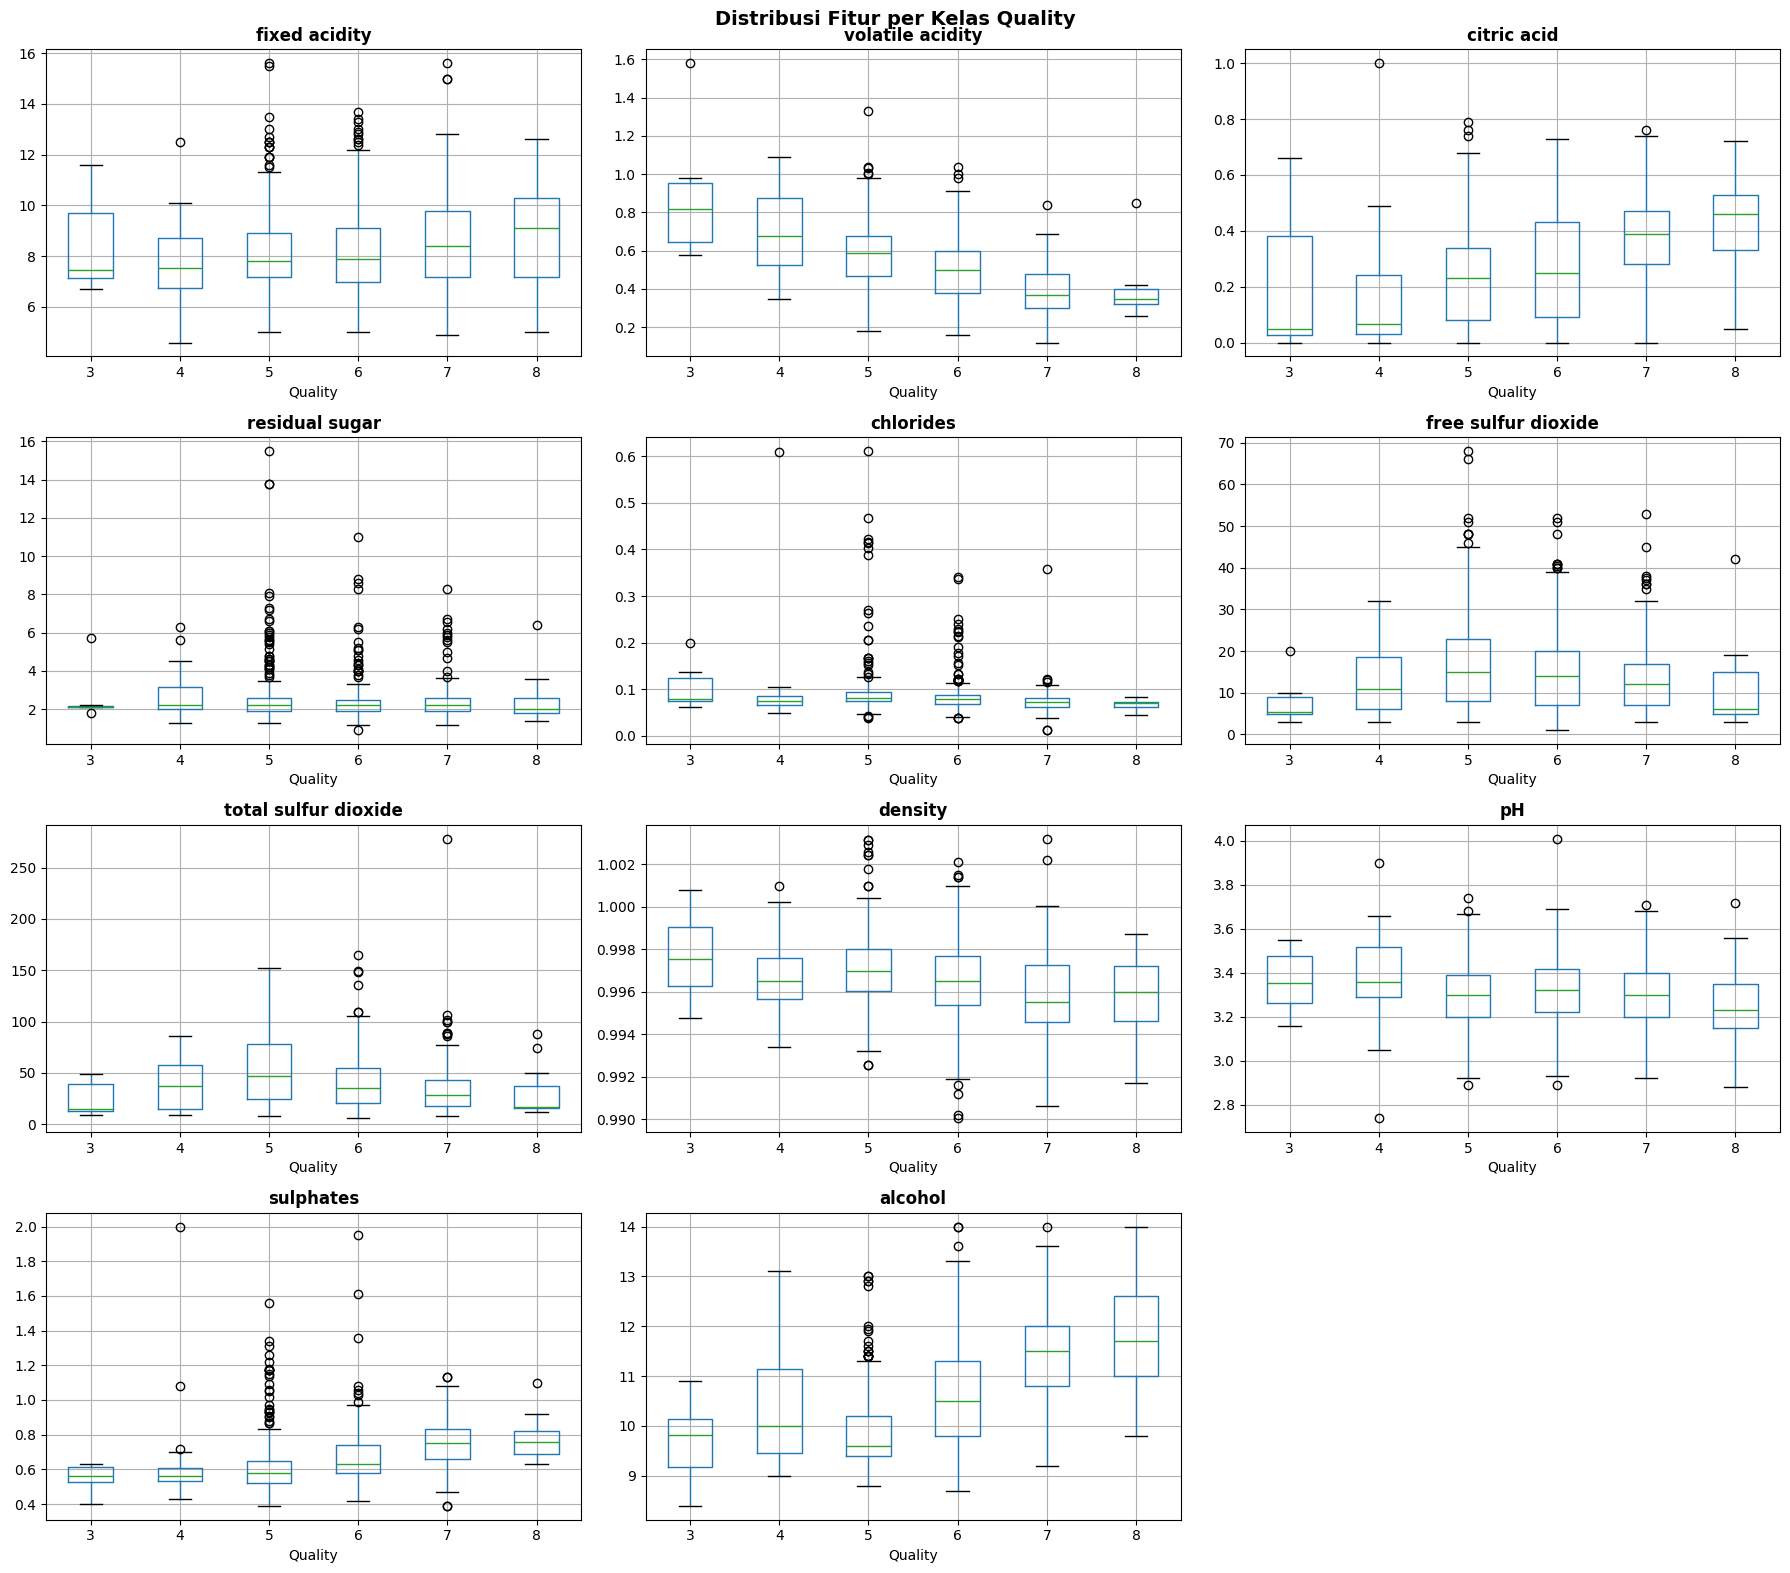

In [14]:
# Distribusi Fitur Berdasarkan Quality

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    train.boxplot(column=feat, by='quality', ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Quality')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur per Kelas Quality', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

1. Volatile Acidity = Semakin tinggi quality, semakin rendah volatile acidity
Ini adalah sinyal paling jelas. Anggur berkualitas rendah (Q=3) punya kadar asam volatil tinggi (sekitar 0.8), sedangkan Q=7–8 jauh lebih rendah (sekitar 0.3). Masuk akal karena volatile acidity yang tinggi membuat anggur terasa asam/cuka.
2. Alcohol = Semakin tinggi quality, semakin tinggi kadar alkohol
Anggur Q=7–8 punya median alkohol lebih tinggi (sekitar 11–12%) dibanding Q=3–4 (sekitar 10%). Ini konsisten dengan penelitian bahwa anggur premium cenderung berkadar alkohol lebih tinggi.
3. Sulphates = Tren naik seiring quality meningkat
Anggur Q=7–8 memiliki median sulphates lebih tinggi (sekitar 0.75) dibanding Q=3–4 (sekitar 0.6). Sulphates berperan sebagai pengawet dan antioksidan yang memperbaiki rasa.
4. Citric Acid = Sedikit tren naik di quality tinggi
Citric acid membantu memberikan kesegaran pada anggur. Kelas Q=7–8 cenderung sedikit lebih tinggi, tapi variasinya besar sehingga trennya tidak terlalu kuat.
5. Chlorides = Semakin tinggi quality, semakin rendah chlorides
Kandungan garam (chlorides) yang rendah dikaitkan dengan kualitas lebih baik. Terlihat Q=7–8 punya median chlorides mendekati 0.05, lebih rendah dari Q=3–5.
6. Fixed Acidity & pH = Tidak ada pola jelas
Distribusinya relatif stabil di semua kelas quality. Artinya kedua fitur ini kurang diskriminatif untuk membedakan kualitas anggur.
7. Residual Sugar = Tidak ada pola jelas
Distribusi gula sisa sangat beragam di semua kelas, dengan banyak outlier. Gula tidak terlalu berpengaruh pada kualitas secara konsisten.
8. Free & Total Sulfur Dioxide = Sedikit lebih tinggi di Q=5–6
Kelas menengah cenderung punya kandungan SO₂ lebih tinggi, tapi trennya tidak linear dan variasinya besar.
9. Density = Anggur berkualitas tinggi cenderung density lebih rendah
Density berkaitan erat dengan kadar alkohol dan gula. Q=7–8 memiliki density sedikit lebih rendah, sejalan dengan kadar alkohol yang lebih tinggi.


## 2. Pembuatan Model
Gunakan model klasifikasi yang sesuai untuk memprediksi nilai quality pada dataset pelatihan. Anda dapat menggunakan model klasifikasi apapun. Evaluasi model Anda menggunakan metrik yang sesuai, seperti akurasi atau confusion matrix, untuk memastikan bahwa model Anda bekerja dengan baik pada data pelatihan.

Train : (685, 11) | Val : (172, 11)


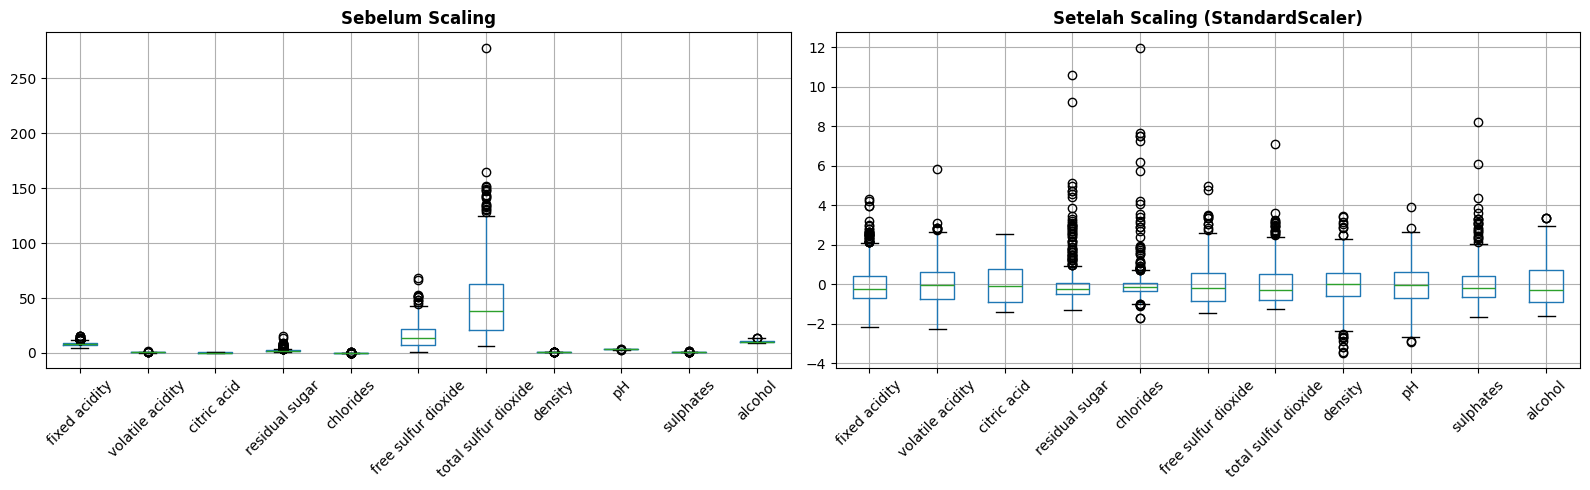


Scaling selesai. Semua fitur kini berskala seragam.


In [17]:
#Preprocessing sebelum memilih model
"""
Menggunakan StandardScale agar setiap fitur memiliki mean=0
dan std=1. Scaler di fit hanya pada data training untuk
menjegah data leakage
"""
TARGET = 'quality'

X = train[FEATURES]
y = train[TARGET]
X_test_full = test[FEATURES]
test_ids = test['Id']

# Stratified split 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape} | Val : {X_val.shape}")

# Fit scaler HANYA pada data training
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_full)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
X_train.boxplot(ax=axes[0], rot=45)
axes[0].set_title('Sebelum Scaling', fontweight='bold')
pd.DataFrame(X_train_sc, columns=FEATURES).boxplot(ax=axes[1], rot=45)
axes[1].set_title('Setelah Scaling (StandardScaler)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nScaling selesai. Semua fitur kini berskala seragam.")

Grafik diatas menampilkan perbandingan distribusi fitur kimia anggur sebelum dan sesudah proses scaling. Pada grafik sebelum scaling (kiri), terlihat perbedaan skala yang sangat besar antar fitur dan total sulfur dioxide memiliki nilai hingga ~270, sementara fitur seperti chlorides dan density hampir tidak terlihat karena nilainya sangat kecil. Perbedaan ini berbahaya karena algoritma seperti SVM dan Logistic Regression menghitung jarak atau gradien antar titik data, sehingga fitur dengan skala besar akan mendominasi hasil perhitungan bukan karena lebih penting, melainkan hanya karena nilainya lebih besar. Setelah diterapkan StandardScaler (grafik kanan), seluruh fitur kini berada pada skala seragam dengan median mendekati 0 dan sebagian besar data berada di rentang -1 hingga +1, sehingga setiap fitur berkontribusi secara proporsional terhadap model.

StandardScaler bekerja dengan rumus z = (x − μ) / σ, yang menghasilkan setiap fitur memiliki mean = 0 dan standar deviasi = 1. Namun yang tidak kalah penting adalah scaler hanya di-fit pada data training, bukan pada seluruh data. Ini dilakukan untuk mencegah data leakage (kebocoran data), yaitu kondisi di mana informasi dari data testing sudah "bocor" ke proses pelatihan. Jika scaler di-fit pada seluruh data terlebih dahulu sebelum dibagi, maka model secara tidak langsung sudah "melihat" karakteristik data testing (mean dan std-nya), sehingga performa model akan terlihat lebih baik dari kondisi nyatanya. Fit dilakukan hanya pada training, lalu transform secara terpisah pada validation dan testing kemudian model dilatih dalam kondisi yang mensimulasikan dunia nyata, di mana data baru yang datang belum pernah dilihat sebelumnya.

Model                     |   Mean Acc |      Std
--------------------------------------------------
Random Forest             |     0.6380 |   0.0150
Gradient Boosting         |     0.6044 |   0.0404
Logistic Regression       |     0.4350 |   0.0109
SVM                       |     0.5036 |   0.0201

Model terbaik: Random Forest


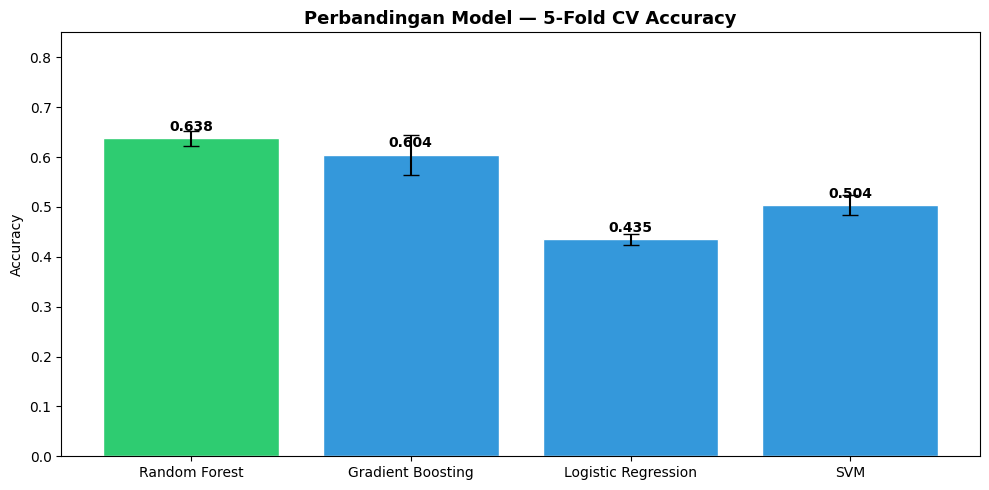

In [18]:
# Pemilihan Model

models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42,
                                                    class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42,
                                               class_weight='balanced'),
    'SVM'                 : SVC(random_state=42, class_weight='balanced'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} | {'Mean Acc':>10} | {'Std':>8}")
print("-" * 50)
for name, model in models.items():
    X_cv = X_train_sc if name in ('Logistic Regression', 'SVM') else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} | {scores.mean():>10.4f} | {scores.std():>8.4f}")

best_name = max(results, key=lambda k: results[k].mean())
print(f"\nModel terbaik: {best_name}")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if k == best_name else '#3498db' for k in results]
means  = [results[k].mean() for k in results]
stds   = [results[k].std()  for k in results]
bars = ax.bar(list(results.keys()), means, yerr=stds,
              color=colors, capsize=6, edgecolor='white')
ax.set_title('Perbandingan Model — 5-Fold CV Accuracy', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 0.85)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
            f'{m:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Berdasarkan hasil perbandingan empat algoritma klasifikasi menggunakan 5-Fold Cross Validation, Random Forest terpilih sebagai model terbaik dengan rata-rata akurasi tertinggi sebesar 63,8% dan standar deviasi yang kecil (0,015), menunjukkan bahwa model ini tidak hanya akurat tetapi juga konsisten di setiap fold validasi. Gradient Boosting berada di posisi kedua dengan akurasi 60,4%, meskipun memiliki standar deviasi yang lebih besar (0,040) yang mengindikasikan performa yang kurang stabil antar fold. SVM menempati posisi ketiga dengan akurasi 50,4%, sedangkan Logistic Regression menghasilkan performa terendah sebesar 43,5%, hal ini dapat dipahami karena Logistic Regression adalah model linear yang kurang mampu menangkap pola non-linear yang kompleks dalam data kualitas anggur. Secara keseluruhan, Random Forest unggul karena kemampuannya sebagai model ensemble yang menggabungkan banyak pohon keputusan, sehingga lebih robust terhadap noise dan class imbalance yang ada pada dataset ini.

In [21]:
# Hyperparameter Tuning (Random Forest(GridSearchCV))
"Mengoptimalkan hyperparameter Random Forest Menggunakan GridSearchCV dengan 5-fold CV"

param_grid = {
    'n_estimators'     : [200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
gs = GridSearchCV(rf_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print(f"\nBest Parameters : {gs.best_params_}")
print(f"Best CV Accuracy: {gs.best_score_:.4f}")

best_model = gs.best_estimator_
print("\nModel optimal siap digunakan.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.6438

Model optimal siap digunakan.


In [23]:
# Evaluasi model
# Evaluasi pada Validation Set

y_pred_val = best_model.predict(X_val)

acc = accuracy_score(y_val, y_pred_val)
f1  = f1_score(y_val, y_pred_val, average='weighted')

print(f"Validation Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-Score (weighted)  : {f1:.4f}")
print()
print(classification_report(y_val, y_pred_val))

Validation Accuracy  : 0.6163 (61.63%)
F1-Score (weighted)  : 0.5970

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.68      0.77      0.72        73
           6       0.57      0.63      0.60        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.62       172
   macro avg       0.45      0.33      0.36       172
weighted avg       0.59      0.62      0.60       172



Model Random Forest menghasilkan Validation Accuracy sebesar 61,63% dan F1-Score weighted 0,597, yang mencerminkan performa cukup baik namun dipengaruhi oleh ketidakseimbangan kelas pada dataset. Performa terbaik terlihat pada kelas 5 dan 6 yang merupakan kelas mayoritas. Untuk kelas 5 mencapai F1-score 0,72 dengan recall 77%, sedangkan kelas 6 dengan F1-score 0,60 dan recall 63%, karena model memiliki cukup banyak sampel untuk belajar pola kedua kelas tersebut. Sebaliknya, kelas 3 dan 4 sama sekali tidak berhasil diprediksi (precision, recall, dan F1-score = 0,00) karena jumlah sampelnya sangat sedikit (hanya 1 dan 5 sampel di data validasi) sehingga model kesulitan mempelajari karakteristiknya. Kelas 7 memiliki F1-score 0,34 dengan recall hanya 27%, menunjukkan model masih sering salah mengklasifikasikan anggur berkualitas tinggi, sementara kelas 8 meskipun precision-nya sempurna (1,00), recall-nya hanya 0,33 yang berarti model hanya berhasil mendeteksi 1 dari 3 sampel kelas tersebut. Secara keseluruhan, rendahnya performa pada kelas minoritas ini adalah konsekuensi langsung dari class imbalance pada dataset, di mana kelas 5 dan 6 mendominasi hampir 82% data sehingga model cenderung bias ke kedua kelas tersebut.

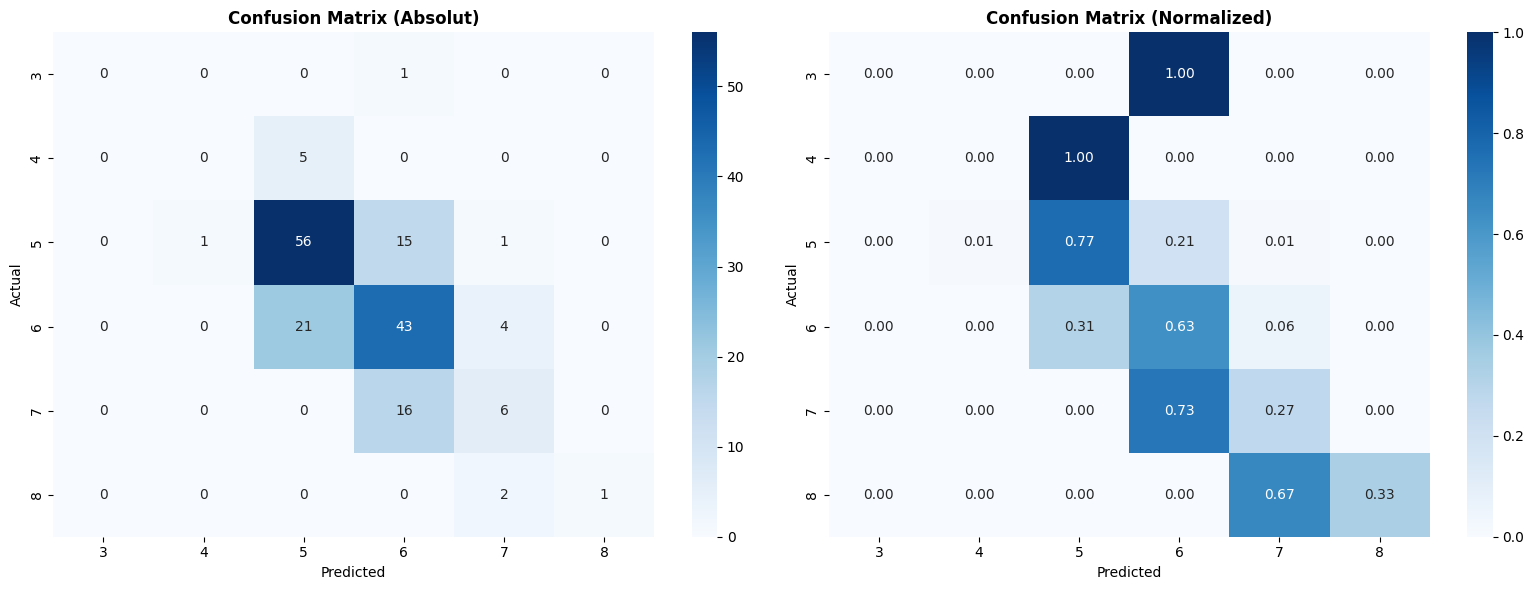

Diagonal = prediksi benar. Model paling baik pada kelas 5 & 6 (mayoritas).


In [25]:
# Confusion Matrix

labels_cm = sorted(y.unique())
cm = confusion_matrix(y_val, y_pred_val, labels=labels_cm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[0])
axes[0].set_title('Confusion Matrix (Absolut)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("Diagonal = prediksi benar. Model paling baik pada kelas 5 & 6 (mayoritas).")


Confusion matrix di atas menampilkan performa model Random Forest dalam memprediksi setiap kelas quality secara detail, baik dalam nilai absolut maupun proporsi. Pada diagonal utama (prediksi benar), terlihat bahwa kelas 5 berhasil diprediksi dengan benar sebanyak 56 sampel (77%) dan kelas 6 sebanyak 43 sampel (63%), yang merupakan performa terbaik karena kedua kelas ini mendominasi dataset. Kelas 7 diprediksi benar sebanyak 16 sampel (73% dari actual), namun masih ada 6 sampel yang salah diprediksi sebagai kelas 6, menunjukkan model kesulitan membedakan anggur berkualitas tinggi dengan yang sedang. Kesalahan terbesar terjadi pada baris kelas 6, di mana 21 sampel yang seharusnya kelas 6 malah diprediksi sebagai kelas 5, hal tersebut merupakan false negative terbanyak dan mencerminkan overlap fitur yang besar antara kedua kelas tersebut. Yang paling mencolok adalah kelas 3 dan 4 tidak berhasil diprediksi sama sekali, seluruh sampel kelas 3 (1 sampel) diprediksi sebagai kelas 6, dan seluruh sampel kelas 4 (5 sampel) diprediksi sebagai kelas 5, karena jumlahnya yang terlalu sedikit membuat model tidak mampu mempelajari polanya. Secara keseluruhan, confusion matrix ini mempertegas bahwa class imbalance adalah tantangan utama. Model bekerja sangat baik untuk kelas mayoritas (5 & 6), namun kesulitan mengenali kelas minoritas (3, 4, dan 8).

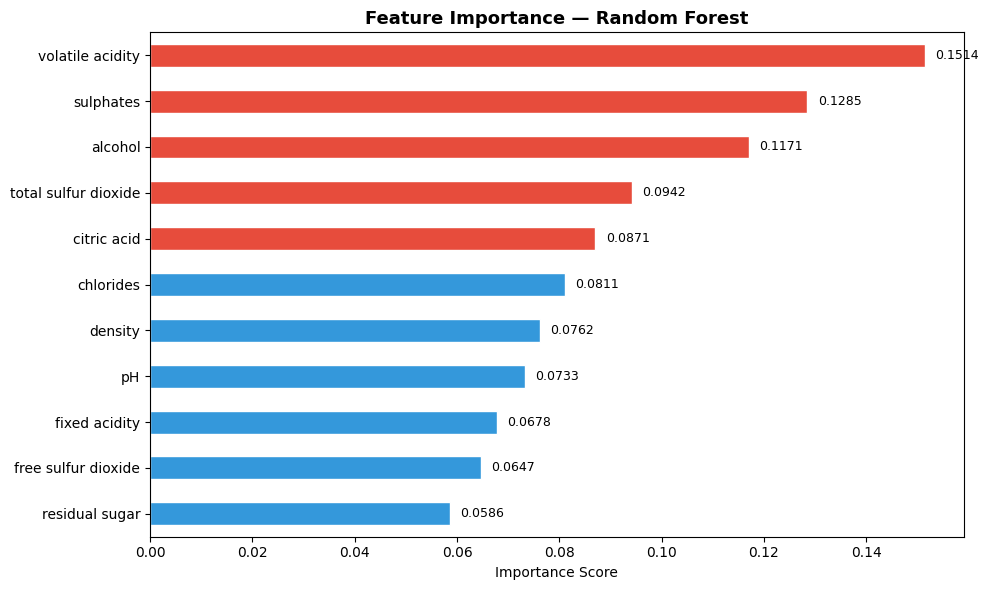


Top 3 Fitur Paling Penting:
  volatile acidity: 0.1514
  sulphates: 0.1285
  alcohol: 0.1171


In [26]:
# Feature Importance

feat_imp = pd.Series(best_model.feature_importances_,
                     index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 3 Fitur Paling Penting:")
for f, v in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {f}: {v:.4f}")

## 4. Prediksi Data Uji
Setelah model terlatih, gunakan model Anda untuk memprediksi nilai quality untuk data uji (data_testing.csv). Simpan hasil prediksi Anda dalam file CSV dengan format yang sesuai. Format dapat didownload pada folder dataset. Pastikan file tersebut berisi Id dan hasil prediksi quality yang Anda buat.

Distribusi prediksi quality:
5    137
6    123
7     26
Name: count, dtype: int64


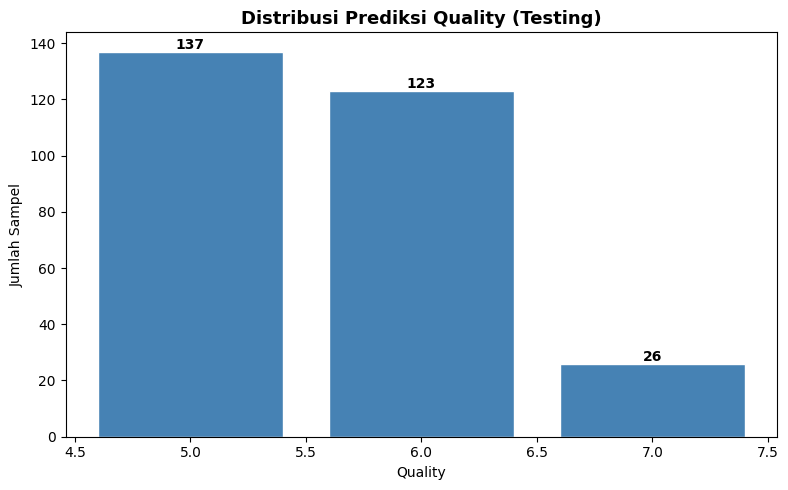

In [27]:
y_test_pred = best_model.predict(X_test_full)

print("Distribusi prediksi quality:")
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
print(pred_dist)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pred_dist.index, pred_dist.values, color='steelblue', edgecolor='white')
for i, v in zip(pred_dist.index, pred_dist.values):
    ax.text(i, v+1, str(v), ha='center', fontweight='bold')
ax.set_title('Distribusi Prediksi Quality (Testing)', fontweight='bold', fontsize=13)
ax.set_xlabel('Quality'); ax.set_ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

Grafik di atas menampilkan distribusi hasil prediksi model Random Forest terhadap 286 sampel data testing. Model memprediksi bahwa sebagian besar anggur memiliki kualitas 5 (137 sampel, sekitar 47,9%) dan kualitas 6 (123 sampel, sekitar 43,0%), sementara hanya 26 sampel (sekitar 9,1%) yang diprediksi berkualitas 7. Tidak ada sampel yang diprediksi masuk ke kelas 3, 4, maupun 8, yang konsisten dengan pola yang sudah terlihat saat evaluasi, model cenderung memprediksi kelas mayoritas karena pengaruh class imbalance pada data training. Secara keseluruhan, distribusi prediksi ini sangat mencerminkan distribusi data training, di mana kelas 5 dan 6 mendominasi, sehingga model lebih memilih memprediksi kedua kelas tersebut dibandingkan kelas ekstrem yang memiliki sedikit sampel referensi saat pelatihan.

In [28]:
# Menyimpan hasil prediksi
hasilprediksi = pd.DataFrame({'Id': test_ids, 'quality': y_test_pred})
hasilprediksi.to_csv('hasilprediksi.csv', index=False)

print("File disimpan!")
print(f"   Shape: {hasilprediksi.shape}")
print()
hasilprediksi.head(10)

File disimpan!
   Shape: (286, 2)



,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6
5,1120,6
6,180,5
7,82,5
8,632,6
9,592,5


In [29]:
# Simpan Model (Deployment)
"""
Model disimpan menggunaan pickle untuk deployment ulang
"""

model_artifact = {
    'model'       : best_model,
    'scaler'      : scaler,
    'features'    : FEATURES,
    'best_params' : gs.best_params_,
    'val_accuracy': acc,
    'val_f1'      : f1,
}

with open('rf_wine_model.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

print("Model disimpan ke rf_wine_model.pkl")
print()

# Demo load & deploy
with open('rf_wine_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

sample_pred = loaded['model'].predict(X_test_full.iloc[:3])
print("Demo prediksi 3 sampel pertama:", sample_pred)
print("Model berhasil diload dan digunakan.")

Model disimpan ke rf_wine_model.pkl

Demo prediksi 3 sampel pertama: [5 6 5]
Model berhasil diload dan digunakan.
